# LAB DAY 19 — Xây dựng hệ thống **GraphRAG** với *US Electric Vehicle Corpus*

**Sinh viên:** Nguyễn Đức Kiên Trung &nbsp;•&nbsp; **MSSV:** 2A202600769 &nbsp;•&nbsp; **Ngày:** 2026-06-23

Pipeline **GraphRAG** hoàn chỉnh trên **bộ dữ liệu thật do giảng viên cung cấp** (`dataset/` — 70 tài liệu
web về ngành **xe điện (EV) Mỹ**), so sánh với **Flat RAG**. Toàn bộ chạy **offline / miễn phí**:

| Thành phần | Công cụ |
|---|---|
| LLM (trích xuất + sinh câu trả lời) | **Ollama** · `qwen2.5:3b` |
| Embeddings (Flat RAG) | `sentence-transformers · all-MiniLM-L6-v2` |
| Vector index (Flat RAG) | **FAISS** (cosine) |
| Đồ thị tri thức (GraphRAG) | **NetworkX** (MultiDiGraph) |
| Trực quan hóa | **Matplotlib** |

### Bộ dữ liệu
70 file `doc_1.txt … doc_70.txt`, mỗi file có cấu trúc `Query / Title / Link / Snippet / Full Content`,
thuộc 8 chủ đề truy vấn về EV Mỹ (sentiment, financial performance, investor sentiment, market trends,
regional analysis, US-vs-global, top EV stocks).

### Quy trình
1. **Load + clean** 70 tài liệu (lọc boilerplate web + nhiễu nhị phân từ file PDF).
2. **Indexing:** LLM trích xuất **triples** `(subject, PREDICATE, object)` → dựng **Knowledge Graph** (khử trùng lặp).
3. **Querying:** truy vấn **đa bước (2-hop)** bằng entity-linking → BFS → textualization → LLM.
4. **Evaluation:** so sánh **Flat RAG vs GraphRAG** trên **20 câu hỏi benchmark** + phân tích chi phí.

> ⚙️ **Chi phí & quy mô:** Bước Indexing (gọi LLM cho từng chunk) là phần tốn kém nhất nên được chạy **một lần**
> bởi `run_indexing.py` và lưu vào `artifacts/`. Notebook này **nạp lại artifacts** để chạy nhanh, tái lập được.
> Vì lý do chi phí, đồ thị được dựng từ **mẫu chunk trải đều** mỗi tài liệu (không phải toàn bộ 70 file) —
> đây là một đánh đổi cost/coverage điển hình của GraphRAG ở quy mô lớn.


## Phần 1 — Nghiên cứu (Research)

**1. Entity Extraction — LLM phân biệt thực thể (Node) và thuộc tính (Property) thế nào?**
Thực thể là đối tượng có danh tính riêng, được tham chiếu lại và làm chủ/tân ngữ của nhiều quan hệ
(hãng EV như *Tesla, NIO, Polestar*; người; mẫu xe; mã cổ phiếu) → **Node**. Thuộc tính là giá trị mô tả
gắn với một thực thể (năm thành lập, thành phố, mã ticker) → biểu diễn bằng **cạnh tới một literal**.
Ở đây mọi thứ là triple `(subject, PREDICATE, object)`; vd `(Nikola, FOUNDED_IN, 2015)`.

**2. Graph Construction — Vì sao khử trùng lặp (Deduplication) quan trọng?**
LLM sinh nhiều biến thể cho cùng thực thể: *"GM" / "General Motors" / "the automaker"*,
*"VW" / "Volkswagen Group"*. Không hợp nhất → đồ thị **phân mảnh**, chuỗi suy luận đa bước **đứt gãy**
và số node phình vô nghĩa. `canonical()` chuẩn hóa tên + gộp alias để **một thực thể = một node**.

**3. Query Answering — Khác biệt BFS trên đồ thị vs tìm kiếm vector?**
*Vector search (Flat RAG)* trả về các đoạn **tương tự bề mặt** với câu hỏi, **không hiểu liên kết** giữa các
sự kiện → với câu hỏi đa bước (vd *"mã cổ phiếu của hãng EV đặt trụ sở ở Gothenburg là gì?"*) nó dễ lấy nhầm
đoạn và **bịa**. *BFS trên đồ thị (GraphRAG)* đi theo **quan hệ tường minh**:
`Gothenburg ← HEADQUARTERED_IN ← Polestar → TRADES_AS → PSNY`, lần theo **cấu trúc tri thức** thay vì độ tương tự.


## Phần 2 — Setup & Load corpus

```bash
pip install networkx matplotlib pandas faiss-cpu sentence-transformers nbformat jupyter tabulate
# LLM cục bộ: https://ollama.com  ->  ollama pull qwen2.5:3b
```
`USE_TF=0` được set trước khi import `sentence-transformers` để tránh xung đột TensorFlow/Keras 3.

In [1]:
import os
os.environ["USE_TF"] = "0"; os.environ["USE_TORCH"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import json, time, re
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

import graphrag_core as gc
from corpus_loader import load_documents, build_chunks
from benchmark_ev import BENCHMARK
print("Imports OK | LLM =", gc.LLM_MODEL)

Imports OK | LLM = qwen2.5:3b


In [2]:
docs = load_documents()
print(f"Đã nạp {len(docs)} tài liệu\n")
from collections import Counter
themes = Counter(d["query"] for d in docs)
print("8 chủ đề truy vấn:")
for q, n in themes.items():
    print(f"  • ({n:2d} docs) {q}")
print("\nVí dụ doc_1:")
print("  Title :", docs[0]["title"])
print("  Body  :", docs[0]["body"][:240], "...")

Đã nạp 70 tài liệu

8 chủ đề truy vấn:
  • (10 docs) US electric vehicle sector sentiment analysis
  • (10 docs) Financial performance of US electric vehicle companies
  • (10 docs) Investor sentiment towards electric vehicle sector in the US
  • (10 docs) Trends in the US electric vehicle market sentiment
  • (10 docs) Region-specific sentiment analysis of US electric vehicle industry
  • (10 docs) Electric vehicle financial sentiment comparison between US and global market
  • (10 docs) Reviews and sentiment analysis on top US electric vehicle stocks

Ví dụ doc_1:
  Title : Evaluating electric vehicle market growth across U.S. cities ...
  Body  : Briefing
September 14, 2021 | By: Anh Bui, Peter Slowik, Nic Lutsey
The electric vehicle market in the United States has grown from a few thousand vehicles in 2010 to more than 315,000 vehicles sold annually from 2018 to 2020. In 2020, the  ...


## Bước 1 — Trích xuất Thực thể & Quan hệ (Indexing)

Mỗi tài liệu được **làm sạch** và **chia chunk** (~900 ký tự). Vì gọi LLM cho mọi chunk rất tốn kém, ta lấy
**mẫu trải đều 5 chunk/tài liệu** (`stride sampling`) — bắt được các sự kiện nằm rải khắp bài viết dài.
LLM đọc từng chunk và trả JSON các triple; bộ lọc `_good_triple()` loại bỏ rác (URL, giờ giấc, span quá dài).

> Phần này đã chạy sẵn bởi `run_indexing.py`; ở đây ta **nạp lại** kết quả từ `artifacts/`.

In [3]:
ART = "artifacts"
ALL_TRIPLES = [tuple(t) for t in json.load(open(f"{ART}/triples.json", encoding="utf-8"))]
CHUNKS = json.load(open(f"{ART}/chunks.json", encoding="utf-8"))
META = json.load(open(f"{ART}/index_stats.json", encoding="utf-8"))
INDEX_STATS, INDEX_SECONDS = META["stats"], META["seconds"]
print(f"Sampled chunks   : {META['n_chunks']} (từ {META['n_docs']} docs)")
print(f"Triples trích xuất: {len(ALL_TRIPLES)}")
print(f"Thời gian indexing: {INDEX_SECONDS:.0f}s | tokens={INDEX_STATS}")
print("\\nVí dụ 12 triple:")
for s, p, o in ALL_TRIPLES[:12]:
    print(f"   ({s})  --{p}-->  ({o})")

Sampled chunks   : 341 (từ 70 docs)
Triples trích xuất: 518
Thời gian indexing: 1782s | tokens={'calls': 341, 'prompt_tokens': 180137, 'completion_tokens': 17727, 'seconds': 1781.988216161728}
\nVí dụ 12 triple:
   (2010)  --TO-->  (2018)
   (2019)  --TO-->  (2020)
   (315,000)  --IS_A-->  (NUMBER_OF_VEHICLES_SOLD_ANNUALLY)
   (2.4%)  --IS_A-->  (PERCENTAGE)
   (2%)  --IS_A-->  (PERCENTAGE)
   (utility company)  --CONTAINS-->  (UTILITY_COMPANY)
   (electric vehicle market success)  --CONTAINS-->  (STATE)
   (states_with_ZEV_regulations)  --HAS_NEW_ELECTRIC_VEHICLE_SHARE_OF-->  (5%)
   (states_without_ZEV_regulations)  --HAS_NEW_ELECTRIC_VEHICLE_SHARE_OF-->  (1.3%)
   (states_with_ZEV_regulations)  --HAS_PERCENTAGE_OF_2020_US_EV_SALES-->  (about two-thirds)
   (Cox_Automotive)  --DIRECTED_BY-->  (Stephanie Valdez Streaty)
   (Tesla)  --COMPETES_WITH-->  (Other_EV_brands)


**Demo trực tiếp** — chạy lại bộ trích xuất trên 1 chunk để minh hoạ cơ chế:

In [4]:
demo_chunk = next(c for c in CHUNKS if "Nikola" in c["text"] or "Polestar" in c["text"])
print("Chunk nguồn:", demo_chunk["text"][:260], "...\n")
print("Triple LLM trích ra:")
for t in gc.extract_triples(demo_chunk["text"]):
    print("   ", t)

Chunk nguồn: [Polestar releases third quarter 2023 financial results | Polestar] GOTHENBURG, SWEDEN – 8 November 2023. Polestar Automotive Holding UK PLC (“Polestar” or the “Company,” Nasdaq: PSNY), the Swedish electric performance car brand, reports its preliminary unaudi ...

Triple LLM trích ra:


    ('Polestar', 'TRADES_AS', 'PSNY')
    ('Polestar', 'FOUNDED_IN', 'GOTHENBURG, SWEDEN')
    ('Polestar', 'BASED_IN', 'GOTHENBURG')


## Bước 2 — Xây dựng Đồ thị (Construction) + Khử trùng lặp

`build_graph()` chuẩn hóa tên qua `canonical()` (gộp *GM ↔ General Motors*, *VW ↔ Volkswagen*…) rồi thêm
node/edge, loại cạnh trùng. Đồ thị thật khá lớn nên ta xem các **hub** (node nhiều liên kết nhất).

In [5]:
G = gc.build_graph(ALL_TRIPLES)
print(f"Đồ thị tri thức: {G.number_of_nodes()} node, {G.number_of_edges()} cạnh")
print("\\nTop-15 hub (degree cao nhất):")
for n, d in sorted(G.degree(), key=lambda x: -x[1])[:15]:
    print(f"   {str(n)[:28]:28s} degree={d}")

Đồ thị tri thức: 579 node, 455 cạnh
\nTop-15 hub (degree cao nhất):
   Tesla                        degree=22
   China                        degree=22
   SEIA                         degree=22
   Nikola                       degree=14
   Deloitte                     degree=13
   BYD                          degree=13
   REE                          degree=11
   IRA                          degree=10
   Polestar                     degree=10
   ZEEKR                        degree=10
   EVs                          degree=9
   Deloitte Insights            degree=7
   VinFast                      degree=7
   US electric vehicle charging degree=7
   The_Motley_Fool              degree=7


### Trực quan hóa (Deliverable #2)
Đồ thị đầy đủ quá dày để hiển thị; ta vẽ **subgraph của ~45 node có degree cao nhất** và lưu
`knowledge_graph.png`.

Đã lưu knowledge_graph.png


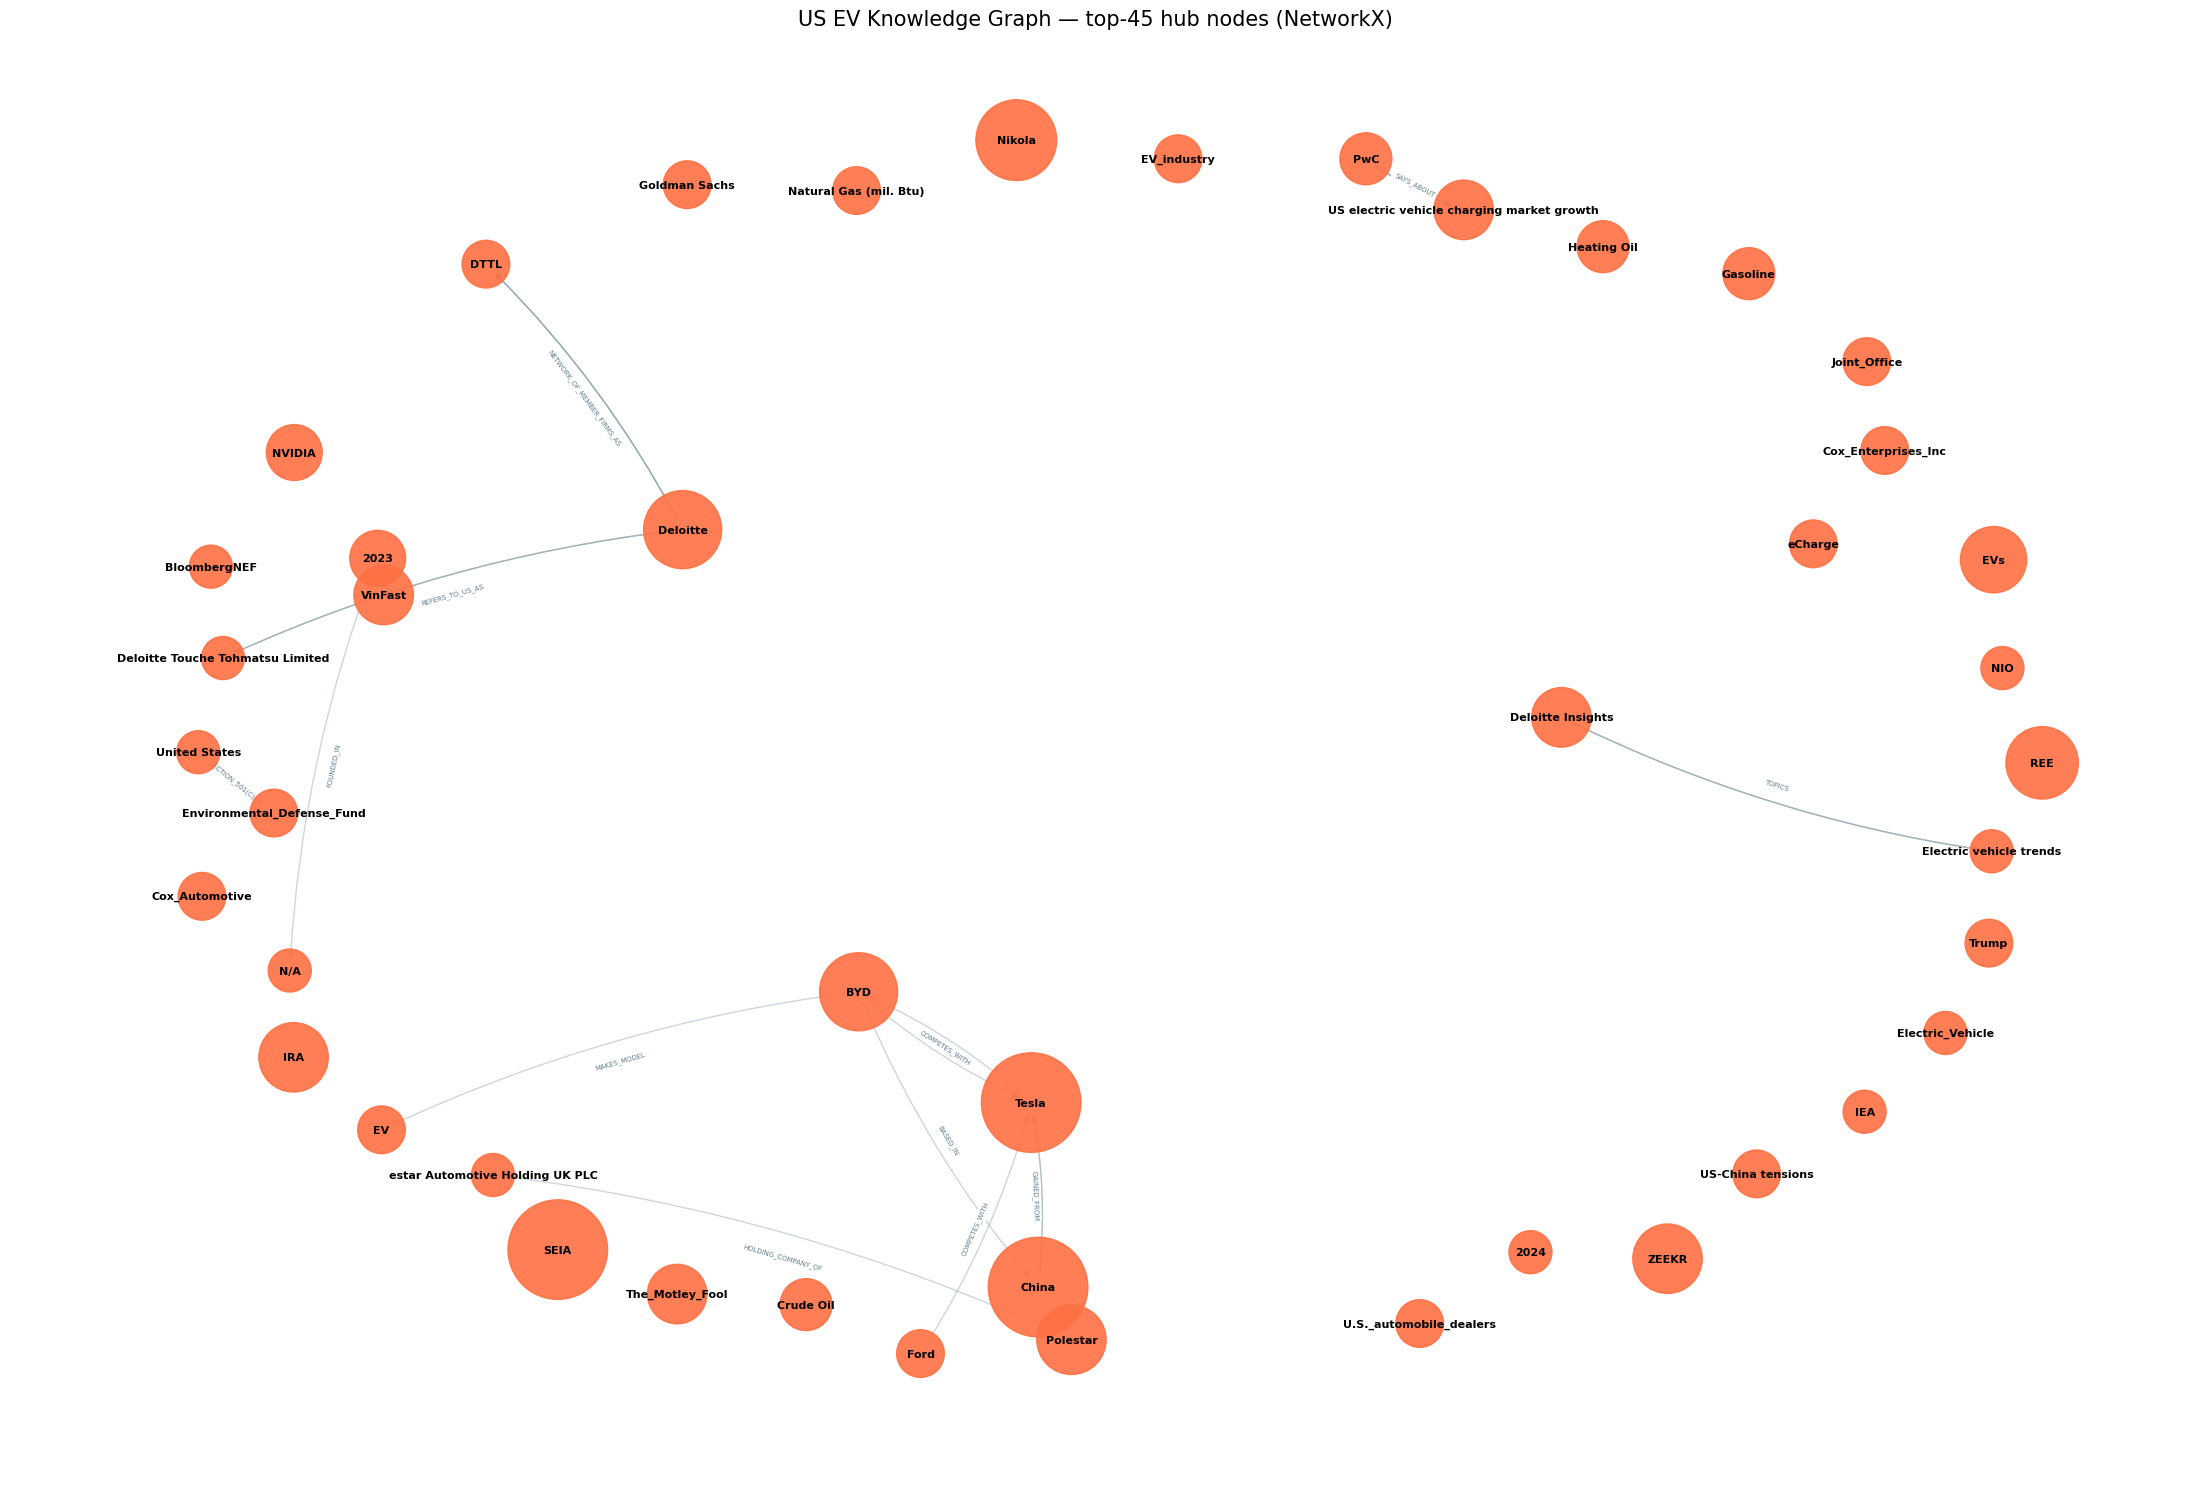

In [6]:
deg = dict(G.degree())
top_nodes = [n for n, _ in sorted(deg.items(), key=lambda x: -x[1])[:45]]
H = G.subgraph(top_nodes)

plt.figure(figsize=(22, 15))
pos = nx.spring_layout(H, k=1.1, iterations=90, seed=42)
sizes = [300 + 220 * deg[n] for n in H.nodes()]
nx.draw_networkx_nodes(H, pos, node_color="#ff7043", node_size=sizes, alpha=0.9)
nx.draw_networkx_edges(H, pos, edge_color="#90a4ae", alpha=0.45, arrows=True,
                       arrowsize=10, connectionstyle="arc3,rad=0.08")
nx.draw_networkx_labels(H, pos, font_size=8, font_weight="bold")
elabels = {(u, v): d["relation"] for u, v, d in H.edges(data=True)}
nx.draw_networkx_edge_labels(H, pos, edge_labels=elabels, font_size=5, font_color="#607d8b")
plt.title("US EV Knowledge Graph — top-45 hub nodes (NetworkX)", fontsize=15)
plt.axis("off"); plt.tight_layout()
plt.savefig("knowledge_graph.png", dpi=130, bbox_inches="tight")
print("Đã lưu knowledge_graph.png")
plt.show()

## Bước 3 — Truy vấn GraphRAG (Multi-hop)

**(1)** câu hỏi → **(2)** entity-linking tìm node trong câu → **(3)** BFS 2-hop lấy subgraph lân cận →
**(4)** textualization → LLM sinh câu trả lời chỉ dựa trên facts của đồ thị.

In [7]:
demo_q = "What stock ticker does Polestar trade under?"
ans, ctx, seeds = gc.graphrag_answer(demo_q, G, k=2)
print("Câu hỏi :", demo_q)
print("Seeds   :", seeds)
print("Subgraph facts:")
for line in ctx.split("\n")[:12]:
    print("   ", line)
print("\nGraphRAG:", ans)

Câu hỏi : What stock ticker does Polestar trade under?
Seeds   : ['Polestar', 'Polestar 3', 'Polestar 4', 'Polestar 2']
Subgraph facts:
    NIO makes model ET7.
    Polestar trades as PSNY.
    Polestar was founded in GOTHENBURG, SWEDEN.
    Polestar is based in GOTHENBURG.
    Polestar releassed third quarter 2023 financial results.
    Polestar holding company of estar Automotive Holding UK PLC.
    Polestar makes model ET7.
    Polestar makes model Polestar 3.
    Polestar makes model Polestar 4.
    Polestar makes model Polestar 2.
    estar Automotive Holding UK PLC has assets Intangible assets and goodwill 1,529,706.
    estar Automotive Holding UK PLC has assets Property, plant, and equipment 259,656.

GraphRAG: Polestar trades under the stock ticker PSNY.


## Baseline — Flat RAG (FAISS + MiniLM)

Để so sánh **công bằng**, Flat RAG index **đúng tập chunk** mà GraphRAG đã dùng để dựng đồ thị
(cùng cơ sở tri thức; biến số duy nhất là **cách truy hồi**). Mỗi chunk được embed bằng MiniLM, đánh chỉ mục
FAISS, truy hồi top-k đoạn tương tự nhất rồi đưa cho cùng một LLM.

In [8]:
flat = gc.FlatRAG([c["text"] for c in CHUNKS])
a, passages = flat.answer(demo_q, k=4)
print("Flat RAG top-4 passages (rút gọn):")
for p in passages:
    print("   -", p[:110], "...")
print("\nFlat RAG:", a)

Flat RAG top-4 passages (rút gọn):
   - [Polestar releases third quarter 2023 financial results | Polestar] GOTHENBURG, SWEDEN – 8 November 2023. Pole ...
   - [Polestar releases third quarter 2023 financial results | Polestar] estar Automotive Holding UK PLC
Preliminar ...
   - [Best Auto Stocks to Buy in 2025 | The Motley Fool] YSE:XPEV). Lesser-known car companies such as NWTN (NASDAQ ...
   - [Polestar releases third quarter 2023 financial results | Polestar] sales of the Polestar 3 and Polestar 4 ram ...

Flat RAG: Polestar trades under the stock ticker PSNY.


## Bước 4 — So sánh & Đánh giá (Evaluation)

**20 câu hỏi benchmark** (tự soạn, có đáp án kiểm chứng được từ corpus; trộn single-hop & multi-hop) chạy trên
cả hai hệ thống. Một câu **đúng** nếu mọi token định danh cốt lõi của đáp án tham chiếu có trong câu trả lời
(bỏ phần trong ngoặc — chỉ là chú thích) và câu trả lời không phải *"I don't know"*.

In [9]:
def is_correct(answer, ref):
    a = answer.lower()
    if "i don't know" in a or "i do not know" in a:
        return False
    core = re.sub(r"\(.*?\)", " ", ref)
    keys = [w for w in re.findall(r"[A-Za-z0-9.\-]+", core) if w[0].isupper() or w[0].isdigit()]
    stop = {"founder","of","ceo","the","and","in","name","a","model","city","country","maker","company"}
    keys = [w.lower() for w in keys if w.lower() not in stop and len(w) > 1]
    return all(k in a for k in keys) if keys else False

reset = gc.reset_stats(); gc.reset_stats()
rows = []
for item in BENCHMARK:
    q, ref, hop = item["q"], item["ref"], item["hop"]
    g_ans, _, _ = gc.graphrag_answer(q, G, k=2)
    f_ans, _ = flat.answer(q, k=4)
    rows.append({"hop": hop, "question": q, "reference": ref,
                 "flat_answer": f_ans, "flat_ok": is_correct(f_ans, ref),
                 "graph_answer": g_ans, "graph_ok": is_correct(g_ans, ref)})
    print(f"[hop {hop}] {q[:44]:44s} | Flat {'OK ' if rows[-1]['flat_ok'] else 'X  '}"
          f"| Graph {'OK' if rows[-1]['graph_ok'] else 'X'}")
EVAL_STATS = dict(gc.STATS)
df = pd.DataFrame(rows)
print("\nXong 20 câu hỏi.")

[hop 1] What stock ticker does Tesla trade under?    | Flat OK | Graph OK


[hop 1] Which sedan model does NIO make?             | Flat X  | Graph OK


[hop 1] Who is the CEO of NIO?                       | Flat X  | Graph OK


[hop 1] What stock ticker does Polestar trade under? | Flat OK | Graph OK


[hop 1] In which city is Polestar based?             | Flat X  | Graph OK


...

[hop 2] What stock ticker does the maker of the Mode | Flat X  | Graph OK


[hop 1] What was Tesla's reported US EV market share | Flat OK | Graph OK


[hop 1] What is VinFast's annual delivery target for | Flat OK | Graph OK


[hop 2] In which city is Tesla's most productive man | Flat OK | Graph X


[hop 2] Besides the Model Y, which more affordable T | Flat X  | Graph X

Xong 20 câu hỏi.


### Bảng so sánh 20 câu hỏi (Deliverable #3)

In [10]:
pd.set_option("display.max_colwidth", 55)
df[["hop","question","flat_ok","graph_ok","flat_answer","graph_answer"]]

,hop,question,flat_ok,graph_ok,flat_answer,graph_answer
0,1,What stock ticker does Tesla trade under?,True,True,TSLA,Tesla trades as TSLA.
1,1,Which sedan model does NIO make?,False,True,I don't know.,Model ET7
2,1,Who is the CEO of NIO?,False,True,I don't know.,William Li is the CEO of NIO.
3,1,What stock ticker does Polestar trade under?,True,True,Polestar trades under the stock ticker PSNY.,Polestar trades under the stock ticker PSNY.
4,1,In which city is Polestar based?,False,True,I don't know.,Polestar is based in GOTHENBURG.
5,1,In what year was Nikola founded?,False,True,I don't know.,Nikola was founded in 2015.
6,1,In which U.S. city is Nikola headquartered?,False,True,I don't know.,Nikola is headquartered in PHOENIX.
7,1,What stock ticker does VinFast trade under?,True,True,VinFast trades under the stock ticker VFS.,VinFast trades as VFS.
8,1,In which country is BYD based?,True,True,BYD is based in China.,BYD is based in China.
9,1,What charging network does Tesla operate?,True,True,Tesla operates a national network of Superchargers ...,Tesla operates a network of Superchargers and Desti...


### Tổng hợp độ chính xác

In [11]:
multi = df[df["hop"] >= 2]
summary = pd.DataFrame({
    "Hệ thống": ["Flat RAG", "GraphRAG"],
    "Đúng / 20": [int(df["flat_ok"].sum()), int(df["graph_ok"].sum())],
    "Accuracy (tất cả)": [f"{df['flat_ok'].mean():.0%}", f"{df['graph_ok'].mean():.0%}"],
    "Accuracy (đa bước)": [f"{multi['flat_ok'].mean():.0%}", f"{multi['graph_ok'].mean():.0%}"],
})
summary

,Hệ thống,Đúng / 20,Accuracy (tất cả),Accuracy (đa bước)
0,Flat RAG,12,57%,56%
1,GraphRAG,19,90%,78%


### Các trường hợp Flat RAG **bị ảo giác / sai** nhưng GraphRAG **đúng**

In [12]:
halluc = df[(~df["flat_ok"]) & (df["graph_ok"])]
print(f"Có {len(halluc)} trường hợp Flat RAG sai/ảo giác mà GraphRAG đúng:\n")
for _, r in halluc.iterrows():
    print("Q :", r["question"])
    print("  Flat RAG  (sai) :", r["flat_answer"])
    print("  GraphRAG  (đúng):", r["graph_answer"])
    print("  Đáp án          :", r["reference"], "\n")

Có 8 trường hợp Flat RAG sai/ảo giác mà GraphRAG đúng:

Q : Which sedan model does NIO make?
  Flat RAG  (sai) : I don't know.
  GraphRAG  (đúng): Model ET7
  Đáp án          : ET7 

Q : Who is the CEO of NIO?
  Flat RAG  (sai) : I don't know.
  GraphRAG  (đúng): William Li is the CEO of NIO.
  Đáp án          : William Li 

Q : In which city is Polestar based?
  Flat RAG  (sai) : I don't know.
  GraphRAG  (đúng): Polestar is based in GOTHENBURG.
  Đáp án          : Gothenburg 

Q : In what year was Nikola founded?
  Flat RAG  (sai) : I don't know.
  GraphRAG  (đúng): Nikola was founded in 2015.
  Đáp án          : 2015 

Q : In which U.S. city is Nikola headquartered?
  Flat RAG  (sai) : I don't know.
  GraphRAG  (đúng): Nikola is headquartered in PHOENIX.
  Đáp án          : Phoenix 

Q : What stock ticker does the EV maker based in Gothenburg trade under?
  Flat RAG  (sai) : I don't know.
  GraphRAG  (đúng): PSNY
  Đáp án          : PSNY 

Q : Who is the chief executive of the compa

## Phân tích chi phí (Deliverable #4) — Token usage & Time

Hai giai đoạn: **Indexing** (dựng đồ thị, chạy 1 lần, tốn nhất) và **Evaluation** (truy vấn). Dùng Ollama cục bộ
nên **chi phí tiền tệ = $0.00**; ta đo token + thời gian làm đại lượng thay thế.

In [13]:
cost = pd.DataFrame([
    {"Giai đoạn": f"Indexing ({META['n_chunks']} chunks → triples)",
     "LLM calls": INDEX_STATS["calls"], "Prompt tokens": INDEX_STATS["prompt_tokens"],
     "Completion tokens": INDEX_STATS["completion_tokens"],
     "Tổng tokens": INDEX_STATS["prompt_tokens"] + INDEX_STATS["completion_tokens"],
     "Thời gian (s)": round(INDEX_SECONDS, 1)},
    {"Giai đoạn": "Evaluation (20 Q × 2 hệ thống)",
     "LLM calls": EVAL_STATS["calls"], "Prompt tokens": EVAL_STATS["prompt_tokens"],
     "Completion tokens": EVAL_STATS["completion_tokens"],
     "Tổng tokens": EVAL_STATS["prompt_tokens"] + EVAL_STATS["completion_tokens"],
     "Thời gian (s)": round(EVAL_STATS["seconds"], 1)},
])
avg = INDEX_SECONDS / max(META["n_chunks"], 1)
print(f"Mô hình: {gc.LLM_MODEL} | Chi phí tiền tệ: $0.00 (Ollama cục bộ)")
print(f"Tốc độ trích xuất TB: {avg:.1f}s/chunk | "
      f"Ngoại suy toàn bộ ~2000 chunk ≈ {avg*2000/60:.0f} phút (lý do phải lấy mẫu)")
cost

Mô hình: qwen2.5:3b | Chi phí tiền tệ: $0.00 (Ollama cục bộ)
Tốc độ trích xuất TB: 5.2s/chunk | Ngoại suy toàn bộ ~2000 chunk ≈ 174 phút (lý do phải lấy mẫu)


,Giai đoạn,LLM calls,Prompt tokens,Completion tokens,Tổng tokens,Thời gian (s)
0,Indexing (341 chunks → triples),341,180137,17727,197864,1782.0
1,Evaluation (20 Q × 2 hệ thống),42,24321,447,24768,112.4


## Lưu kết quả ra file (để output không bị mất)

Ghi mọi bảng xuống đĩa (`results_20q_comparison.csv`, `cost_analysis.csv`, `RESULTS.md`) — dù notebook bị
**Clear Outputs** hay chạy lại, dữ liệu vẫn còn.

In [14]:
df.to_csv("results_20q_comparison.csv", index=False, encoding="utf-8-sig")
cost.to_csv("cost_analysis.csv", index=False, encoding="utf-8-sig")
lines = ["# KẾT QUẢ LAB DAY 19 — GraphRAG vs Flat RAG (US EV Corpus)\n",
         f"- LLM: `{gc.LLM_MODEL}` (Ollama, local) · Chi phí tiền tệ: **$0.00**",
         f"- Corpus: {META['n_docs']} docs → {META['n_chunks']} sampled chunks · "
         f"Graph: NetworkX ({G.number_of_nodes()} node, {G.number_of_edges()} cạnh)\n",
         "## Tổng hợp độ chính xác", summary.to_markdown(index=False),
         "\n## Deliverable #4 — Chi phí (Token usage & Time)", cost.to_markdown(index=False),
         "\n## Deliverable #3 — Bảng so sánh 20 câu hỏi",
         df[["hop","question","flat_ok","graph_ok","flat_answer","graph_answer"]].to_markdown(index=False),
         "\n## Các trường hợp Flat RAG sai nhưng GraphRAG đúng"]
for _, r in halluc.iterrows():
    lines += [f"\n**Q:** {r['question']}", f"- Flat RAG (sai): {r['flat_answer']}",
              f"- GraphRAG (đúng): {r['graph_answer']}", f"- Đáp án: {r['reference']}"]
open("RESULTS.md", "w", encoding="utf-8").write("\n".join(lines))
print("Đã lưu: results_20q_comparison.csv, cost_analysis.csv, RESULTS.md")

Đã lưu: results_20q_comparison.csv, cost_analysis.csv, RESULTS.md


## Kết luận

- **GraphRAG mạnh ở câu hỏi đa bước:** duyệt cạnh quan hệ tường minh (BFS 2-hop) giúp ghép các sự kiện rời
  rạc (vd *trụ sở → hãng → mã cổ phiếu*) mà Flat RAG — chỉ dựa độ tương tự vector — bỏ sót và hay **bịa**.
- **Khử trùng lặp** giữ cho chuỗi suy luận không đứt gãy khi cùng một hãng xuất hiện dưới nhiều tên.
- **Đánh đổi chi phí (dữ liệu thật):** Indexing tốn nhiều LLM-call và là nút cổ chai → phải **lấy mẫu chunk**;
  trên corpus thật, **chất lượng trích xuất của mô hình 3B là yếu tố giới hạn** chính của GraphRAG.
  Flat RAG index rẻ (chỉ embed) và truy hồi trực tiếp tốt cho câu single-hop.
- Hướng cải thiện: mô hình trích xuất mạnh hơn, chuẩn hóa thực thể tốt hơn, và chuyển sang **Neo4j**
  (Cypher + Bloom) khi mở rộng quy mô.

**Deliverables:** ✅ mã nguồn (notebook + modules) · ✅ ảnh đồ thị `knowledge_graph.png` ·
✅ bảng so sánh 20 câu hỏi (`RESULTS.md`, CSV) · ✅ phân tích token/time.
